In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([0.2, 0.0, 0.1])

train_file = "../experiment_data/tape_data/11_noded/n11_traj1_tape_dataset_interp_11.npz"
valid_file = "../experiment_data/tape_data/11_noded/n11_tape_test_dataset.npz"


In [3]:
from properties import TapeN11Properties

properties = TapeN11Properties(mass=-0.005)
print(properties)

TapeN11Properties(length=None, r0=0.005, axs=None, jxs=None, ixs1=None, ixs2=None, density=600.0, E=1000000.0, N=11, start=Array([0., 0., 0.], dtype=float64), end=Array([1.05660479, 0.        , 0.04239192], dtype=float64), mass=-0.005)


In [4]:
params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(42),
    hidden=(10,),
    which_case="baseline",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh",
)

model_cls = StructuredBrazierCholeskyEnergyNN

# final_model, train_history, valid_history = train_model(properties=properties, model_cls=model_cls, params=params, train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2)

In [5]:
final_model, train_history, valid_history = train_model(
    properties=properties,
    model_cls=model_cls,
    params=params,
    train_file=train_file,
    valid_file=valid_file,
    n_epochs=1000,
    lr=5e-2,
    max_dlambda=1e-3,
    iters=10,
    ls_steps=10,
    abs_tol=5e-4,
    rel_tol=1e-4,
    fail_on_nonconvergence=False,
    hessian_reg_strength=1e-6,
    valid_every=10,
)

/Users/radha/GitRepos/dismech-jax/examples/slinky/slinky_2D/util.py:346: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)


Epoch 000 | Train: 7.755e-02 | Valid: 2.981e-02
Epoch 100 | Train: 5.137e-03 | Valid: 7.273e-03
Epoch 200 | Train: 5.035e-03 | Valid: 6.114e-03
Epoch 300 | Train: 4.165e-03 | Valid: 1.102e-02
Epoch 400 | Train: 3.498e-03 | Valid: 1.191e-02
Epoch 500 | Train: 3.521e-03 | Valid: 1.291e-02
Epoch 600 | Train: 2.741e-03 | Valid: 1.016e-02
Epoch 700 | Train: 2.613e-03 | Valid: 9.735e-03
Epoch 800 | Train: 2.918e-03 | Valid: 9.786e-03
Epoch 900 | Train: 2.882e-03 | Valid: 9.665e-03


1000


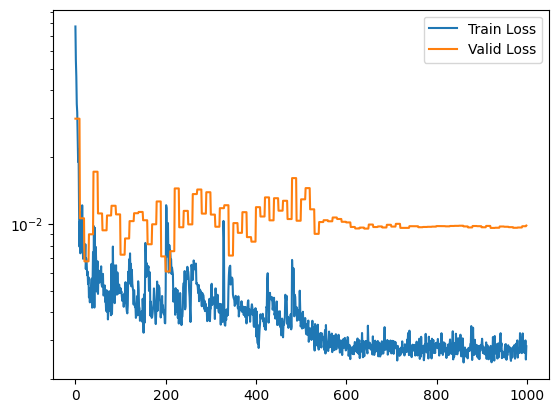

In [6]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [7]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
train = Dataset.load(train_file)

pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)
pred_train = predict(final_model, base, aux, train.idx_b, train.xb, train.lambdas)

/var/folders/z0/3frv2l990hb5ryd49z8vm4w80000gn/T/ipykernel_57861/1889145442.py:1: RuntimeWarning: Mass is non-positive; if this is because gravity is in +z, ignore, but if this is not the intention please correct.
  base, aux = get_slinky(properties)


In [8]:
animate(pred_train[0])

In [9]:
animate(train.qs[0])

In [10]:
animate(pred[0])

In [11]:
animate(pred[0])

In [12]:
animate(valid.qs[0])

In [13]:
animate(valid.qs[1])

In [14]:
animate(valid.qs[2])

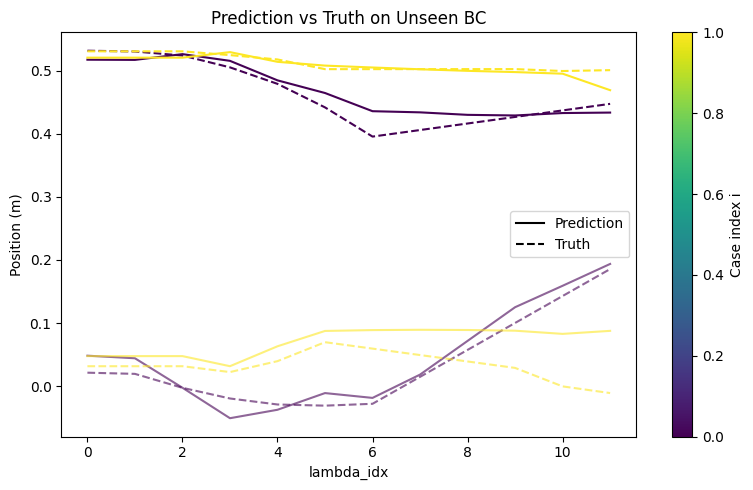

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))
center_node = properties.N // 2

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4*center_node + 0], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4*center_node + 0], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 4*center_node + 2], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 4*center_node + 2], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()